In [1]:
from dotenv import load_dotenv
from IPython.display import display, Markdown

In [2]:
load_dotenv()

True

#### Define State

In [3]:
from collections.abc import Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage

from typing import Annotated
from langgraph.graph import add_messages

add_messages is a reducer function

> It defines how to combine the current state with new incoming data in a structured way

Annotated lets you attach metadata to a type

> in our case, state graph will use the reducer fn to merge the old and new values rather than overwriting them

This allows LangGraph to merge the messages of the state returned by each node to the message field of the previous state

In [4]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

#### Define Nodes

In [5]:
from langchain_core.messages import HumanMessage, AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

In [6]:
chat = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite-preview",
    temperature = 0.6,
    max_output_tokens = 100,
    seed = 0
)

In [7]:
def ask_ques(state: State) -> State:
    print("\n", state, "\n")

    ai_msg = "Hi! How can I help you?"
    print("AI: ", ai_msg)
    
    hum_msg = input(ai_msg)
    print("Human: ", hum_msg)

    return State(messages = [AIMessage(ai_msg), HumanMessage(hum_msg)])    

In [8]:
def chatbot(state: State) -> State:
    print("\n", state, "\n")

    print("Entering Chatbot...")

    response = chat.invoke(state["messages"])
    display(Markdown(StrOutputParser().invoke(response)))

    return State(messages = [response])

In [9]:
def ask_more(state: State) -> State:
    print("\n", state, "\n")

    ai_msg = "Would you like to ask another question? (yes/no)"
    print("AI: ", ai_msg)
    
    hum_msg = input(ai_msg)
    print("Human: ", hum_msg)

    return State(messages = [AIMessage(ai_msg), HumanMessage(hum_msg)])

#### Define Routing Function

In [10]:
def routing_fn(state: State) -> str:
    if state["messages"][-1].content == "yes":
        return "yes"

    else:
        return "no"

#### Define Graph

In [11]:
from langgraph.graph import StateGraph

In [12]:
graph = StateGraph(State)

In [13]:
graph.add_node("Ask Question", ask_ques)
graph.add_node("ChatBot", chatbot)
graph.add_node("Ask More", ask_more)

graph.add_edge("__start__", "Ask Question")
graph.add_edge("Ask Question", "ChatBot")
graph.add_edge("ChatBot", "Ask More")

graph.add_conditional_edges(
    source = "Ask More",
    path = routing_fn,
    path_map = {"yes": "Ask Question", "no": "__end__"}
)

In [14]:
graph = graph.compile()

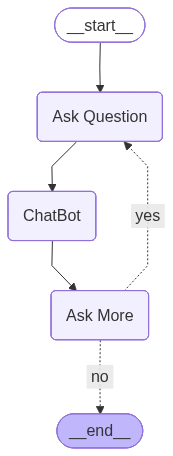

In [15]:
graph

#### Test the graph

In [16]:
graph.invoke(State(messages = []))


 {'messages': []} 

AI:  Hi! How can I help you?
Human:  Give me a famous but short poem. Write the poem only.

 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='1a3b5214-e758-4a76-9beb-247853c3e8ba', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Give me a famous but short poem. Write the poem only.', additional_kwargs={}, response_metadata={}, id='78298b00-5927-47cf-98f7-1805e8285a65')]} 

Entering Chatbot...


I wandered lonely as a cloud
That floats on high o'er vales and hills,
When all at once I saw a crowd,
A host, of golden daffodils;
Beside the lake, beneath the trees,
Fluttering and dancing in the breeze.


 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='1a3b5214-e758-4a76-9beb-247853c3e8ba', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Give me a famous but short poem. Write the poem only.', additional_kwargs={}, response_metadata={}, id='78298b00-5927-47cf-98f7-1805e8285a65'), AIMessage(content=[{'type': 'text', 'text': "I wandered lonely as a cloud\nThat floats on high o'er vales and hills,\nWhen all at once I saw a crowd,\nA host, of golden daffodils;\nBeside the lake, beneath the trees,\nFluttering and dancing in the breeze.", 'extras': {'signature': 'EjQKMgERTTIPVNnrBJM6NJThJnTopL2ldUqQeM9JA4nJ/IOtngmo8PZnO6vDpiLciYlvbDph'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f50f5-62ae-7ea1-ab6b-dbe65fe68c32-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2

William Wordsworth


 {'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='1a3b5214-e758-4a76-9beb-247853c3e8ba', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Give me a famous but short poem. Write the poem only.', additional_kwargs={}, response_metadata={}, id='78298b00-5927-47cf-98f7-1805e8285a65'), AIMessage(content=[{'type': 'text', 'text': "I wandered lonely as a cloud\nThat floats on high o'er vales and hills,\nWhen all at once I saw a crowd,\nA host, of golden daffodils;\nBeside the lake, beneath the trees,\nFluttering and dancing in the breeze.", 'extras': {'signature': 'EjQKMgERTTIPVNnrBJM6NJThJnTopL2ldUqQeM9JA4nJ/IOtngmo8PZnO6vDpiLciYlvbDph'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f50f5-62ae-7ea1-ab6b-dbe65fe68c32-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2

{'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='1a3b5214-e758-4a76-9beb-247853c3e8ba', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Give me a famous but short poem. Write the poem only.', additional_kwargs={}, response_metadata={}, id='78298b00-5927-47cf-98f7-1805e8285a65'),
  AIMessage(content=[{'type': 'text', 'text': "I wandered lonely as a cloud\nThat floats on high o'er vales and hills,\nWhen all at once I saw a crowd,\nA host, of golden daffodils;\nBeside the lake, beneath the trees,\nFluttering and dancing in the breeze.", 'extras': {'signature': 'EjQKMgERTTIPVNnrBJM6NJThJnTopL2ldUqQeM9JA4nJ/IOtngmo8PZnO6vDpiLciYlvbDph'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f50f5-62ae-7ea1-ab6b-dbe65fe68c32-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens':